In [1]:
#!pip install nbconvert[webpdf]
#!pip install openpyxl

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy as stats
import base64

from scipy.stats import linregress
from functools import reduce
from urllib.parse import urlencode, urlunparse,quote, quote_plus
from IPython.display import FileLink,display, HTML

In [3]:
import os
contenu = os.listdir('../../../')
print(contenu)

['13 x 18 cm. (2).pdf', '20102020 Contrat Prestation FOUR SARL - v1.docx', '2021 - 01.2022 Final Process Review.pdf', '20210203_ODISSEO_STEERCO.pptx', '4500128037  Poste10 - NEBIG VERPAKKINGEN BV.docx', '45xxx  Poste20 - ddd.docx', 'Accord Commercial  1 Rexel France_2019 - Adisseo.pdf', 'amtn2005.xls', 'Analyse panel fournisseur 2013-2014.ppt', 'Archilog - Contrat 2020 - 30.3.2020.pdf', 'Avenant 2 - Contrat cadre Technip-ADisseo.docx', 'bilan decembre.pdf', 'Blocs-notes OneNote', 'cerfa_11796-01.pdf', 'CertExchange.p7c', 'chrome', 'Classeur1 (Enregistré automatiquement).xlsx', 'Classeur1 (version 1).xlsb.xlsx', 'Classeur1.xlsx', 'Classeur2(Récupération automatique).xlsx', 'Commande 4210071651 KSB SAS POMPES - Annexe 1A.pdf', 'Commande 4210151994 CRISTAL LIFE (1).pdf', 'Commande 4220029280 SUEZ RR IWS CHEMICALS FRANCE-signed.pdf', 'Commande 4220031812 SUEZ RR IWS CHEMICALS FRANCE.pdf', 'Commande 4230002260 NALCO FRANCE.pdf', 'Commande 4230002264 NALCO FRANCE.pdf', 'Commande 4230002275 N

In [4]:
def read_cred():
    f = open("../../../cred.txt", "r")
    cred = f.read()
    f.close()
    return cred

In [5]:
urlBase = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?'
credentials = read_cred()

In [6]:
def get_OI(url,start,end,interval='PT1M',tag='xx',auth='xx',hS='00',hF='23'):
	url_all =url+'data-reference='+tag+'&aggregation=TIME'+'&aggregation-function=MEAN'+"&from="+start+"T"+hS+"%3A00%3A00.000Z&to="+end+"T"+hF+"%3A59%3A59.000Z&aggregation-period="+interval
	#print(url_all,auth)
	try:
		d_data = pd.read_json(url_all,storage_options={ 'Authorization': 'basic '+ auth})
	except:
		print("Error with tag ",tag)
		print("start",tag)
		return None		
	# print(d_data['values'][0])
	arr = np.asarray(np.asarray(d_data['values'])[0])
	return d_data['values'][0]

In [7]:
def get_data(tags,start, end):
    liste = list(range(0))
    for tag in tags:
        urlTag = quote(tag, safe=':/?#[]@!$&\'()*+,;=')
        data = get_OI(urlBase,start,end,'PT20M',urlTag,credentials,'00','23')
        df = pd.DataFrame(data)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')
        df = df.rename(columns={'value':tag})
        liste.append(df)
    return liste

In [8]:
def merge_data(liste):
    df = reduce(lambda left,right : pd.merge(left, right,left_index=True,right_index=True,how='outer'),liste)
    return df

In [9]:
def detecter_campagnes(df, seuil_jours=30):
    """
    Détecte les campagnes et ajoute plusieurs colonnes d'information
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    
    df = df.sort_index()
    
    # Calculer les différences
    diff_jours = df.index.to_series().diff().dt.days
    
    # Détecter les nouvelles campagnes
    nouvelle_campagne = (diff_jours > seuil_jours) | (diff_jours.isna())
    
    # Numéro de campagne
    df['campagne'] = nouvelle_campagne.cumsum()
    
    # Date de début de chaque campagne
    df['debut_campagne'] = df.groupby('campagne').apply(lambda x: x.index.min()).loc[df['campagne']].values
    
    # Nombre de jours depuis le début de la campagne
    df['jour_campagne'] = (df.index - df['debut_campagne']).days
    
    return df


In [10]:
def detecter_campagnes_v2(df, seuil_jours=3):
    df = df.sort_index().copy()

    # Calcul de l'écart de temps entre deux points consécutifs
    deltas = df.index.to_series().diff()

    # Nouvelle campagne si delta > seuil_jours
    nouvelle_campagne = deltas > pd.Timedelta(days=seuil_jours)

    # Numérotation : on cumule les True
    df["campagne"] = nouvelle_campagne.cumsum() + 1

    # Ajout colonne mois-année au format mm-aa
    df["mois_annee"] = df.index.strftime("%y-%m")
    #df["mois_annee_dt"] = pd.to_datetime(df.index.to_period('M').astype(str))
    df["mois_annee_dt"] = df.index.tz_localize(None).to_period('M').to_timestamp()
    #df["mois_annee_dt"] = pd.to_datetime(df["mois_annee"], format="%m-%y")

    return df

In [11]:
def separer_elements(df):
    """
    Sépare le dataframe en deux : un pour l'élément M et un pour l'élément R.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes timestamp, M_* et R_*
    
    Returns:
    --------
    tuple (df_M, df_R)
        df_M : DataFrame avec timestamp, M_Poids, M_UV_Auto, M_Labo, M_Num, M_Campagne
        df_R : DataFrame avec timestamp, R_Poids, R_UV_Auto, R_Labo, R_Num, R_Campagne
    """
    
    # DataFrame pour M : ne garder que les lignes où M_Poids est non nul
    df_M = df[df['A1000M_Poids'].notna()][['A1000M_Poids', 'A1000M_UV_Auto', 'A1000M_Labo', 'A1000M_Num', 'M_Campagne']].copy()
    df_M = df_M.rename(columns={'M_Campagne':'campagne'})
    
    # DataFrame pour R : ne garder que les lignes où R_Poids est non nul
    df_R = df[df['A1000R_Poids'].notna()][['A1000R_Poids', 'A1000R_UV_Auto', 'A1000R_Labo', 'A1000R_Num', 'R_Campagne']].copy()
    df_R = df_R.rename(columns={'R_Campagne':'campagne'})
        
    return df_M, df_R

In [12]:
def ajouter_element_campagne(df, fill_empty=False):
    """
    Ajoute trois colonnes au dataframe : 'Element' (M ou R), 'M_Campagne' et 'R_Campagne'.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes M_Poids et R_Poids
    fill_empty : bool, default=False
        Si True, propage l'élément sur les lignes vides (forward fill)
        Si False, les lignes sans données restent à NaN
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame avec les nouvelles colonnes 'Element', 'M_Campagne' et 'R_Campagne'
    """
    import numpy as np
    
    # Créer une copie pour ne pas modifier l'original
    df_result = df.copy()
    
    # Identifier l'élément actif basé uniquement sur M_Poids et R_Poids
    df_result['Element'] = np.where(
        df_result['A1000M_Poids'].notna(),
        'M',
        np.where(
            df_result['A1000R_Poids'].notna(),
            'R',
            np.nan
        )
    )
    
    # Détecter les transitions d'élément sur toutes les lignes (y compris NaN)
    element_change = (df_result['Element'] != df_result['Element'].shift()) & df_result['Element'].notna()
    
    # Initialiser les colonnes de campagne
    df_result['M_Campagne'] = np.nan
    df_result['R_Campagne'] = np.nan
    
    # Compteurs de campagne
    m_counter = 0
    r_counter = 0
    
    # Parcourir le dataframe pour attribuer les numéros de campagne
    for idx in df_result.index:
        if df_result.loc[idx, 'Element'] == 'M':
            if element_change.loc[idx]:
                m_counter += 1
            df_result.loc[idx, 'M_Campagne'] = m_counter
        elif df_result.loc[idx, 'Element'] == 'R':
            if element_change.loc[idx]:
                r_counter += 1
            df_result.loc[idx, 'R_Campagne'] = r_counter
    
    # S'assurer que les compteurs commencent à 1 si des valeurs existent
    if df_result['M_Campagne'].notna().any() and df_result['M_Campagne'].min() == 0:
        df_result.loc[df_result['M_Campagne'].notna(), 'M_Campagne'] += 1
    if df_result['R_Campagne'].notna().any() and df_result['R_Campagne'].min() == 0:
        df_result.loc[df_result['R_Campagne'].notna(), 'R_Campagne'] += 1
    
    return df_result

In [13]:
def reincrementer_campagnes_par_temps(df, jours_seuil=3):
    """
    Réincrémente les numéros de campagne en fonction des écarts de temps entre les mesures.
    Si l'écart entre deux lignes dépasse le seuil, le numéro de campagne est incrémenté.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame avec timestamp en index (datetime) et une colonne de campagne
    jours_seuil : int or float, default=3
        Nombre de jours au-delà duquel on incrémente la campagne
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame avec les numéros de campagne mis à jour
    """

    # Créer une copie pour ne pas modifier l'original
    df_result = df.copy()
    
    # Identifier la colonne de campagne (M_Campagne ou R_Campagne)
    #if 'M_Campagne' in df_result.columns:
    col_campagne = 'campagne'
    #elif 'R_Campagne' in df_result.columns:
    #    col_campagne = 'R_Campagne'
    #else:
    #    raise ValueError("Le DataFrame doit contenir une colonne M_Campagne ou R_Campagne")
    
    # Calculer les écarts de temps entre les lignes
    time_diff = df_result.index.to_series().diff()
    
    # Détecter les sauts de campagne (écart > seuil)
    saut_campagne = time_diff > pd.Timedelta(days=jours_seuil)
    
    # Réincrémenter les campagnes
    df_result[col_campagne] = saut_campagne.cumsum() + 1

    # Ajout colonne mois-année au format mm-aa
    df_result["mois_annee"] = df_result.index.strftime("%y-%m")
    df_result["mois_annee_dt"] = df_result.index.tz_localize(None).to_period('M').to_timestamp()
    return df_result

In [14]:
def filtering(df):
    df = df.dropna(how="all")
    df = df[(df['A1000M_Poids']>700) & (df['A1000M_Poids']<1300)]
    df = df[(df['A1000M_UV_Auto']>800_000) & (df['A1000M_UV_Auto']<1_300_000)]
    df = df[(df['A1000M_Labo']>700_000) & (df['A1000M_Labo']<1_300_000)]
    df = df.dropna(how="all", subset=['A1000M_Poids','A1000R_Poids'])
    return df

In [15]:
def plot_data(liste, tags):
    for tag in tags:
        plt.figure(figsize=(18,6))
        
        # Calcul de la moyenne et de la médiane
        moyenne = liste[tag].mean()
        mediane = liste[tag].median()
        
        # Subplot 1 : Scatter plot
        plt.subplot(121)
        plt.scatter(liste.index, liste[tag], label=tag, c='b', alpha=0.3)
        plt.title((tag))
        
        # Lignes horizontales pour moyenne et médiane
        plt.axhline(y=moyenne, color='red', linestyle='--', linewidth=1, label=f'Moyenne: {moyenne:.2f}')
        plt.axhline(y=mediane, color='violet', linestyle='--', linewidth=1, label=f'Médiane: {mediane:.2f}')
        
        plt.legend()
        
        # Subplot 2 : Histogramme
        plt.subplot(122)
        sns.histplot(liste[tag], label=tag, kde=True, common_norm=True)
        
        # Lignes verticales pour moyenne et médiane dans l'histogramme
        plt.axvline(x=moyenne, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {moyenne:.2f}')
        plt.axvline(x=mediane, color='violet', linestyle='--', linewidth=2, label=f'Médiane: {mediane:.2f}')
        
        plt.legend()

In [16]:
def plot_data_v2(liste, tags):
    for tag in tags:
        plt.figure(figsize=(18,6))
        
        # Calcul de la moyenne et de la médiane
        moyenne = liste[tag].mean()
        mediane = liste[tag].median()
        
        # Subplot 1 : Scatter plot
        plt.subplot(121)
        
        # Utiliser l'index original pour l'affichage
        plt.scatter(liste.index, liste[tag], label=tag, c='b', alpha=0.3)
        plt.title((tag))
        
        # Lignes horizontales pour moyenne et médiane
        plt.axhline(y=moyenne, color='red', linestyle='--', linewidth=1, label=f'Moyenne: {moyenne:.2f}')
        plt.axhline(y=mediane, color='violet', linestyle='--', linewidth=1, label=f'Médiane: {mediane:.2f}')
        
        # Ajout de la courbe de tendance
        x = np.arange(len(liste.index))  # Valeurs numériques pour la régression
        y = liste[tag].values
        
        # Filtrer les valeurs NaN
        mask = ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if len(x_clean) > 1:
            # Régression linéaire avec numpy
            coeffs = np.polyfit(x_clean, y_clean, 1)
            line = np.polyval(coeffs, x)
            
            # Calcul du R²
            y_pred = np.polyval(coeffs, x_clean)
            ss_res = np.sum((y_clean - y_pred) ** 2)
            ss_tot = np.sum((y_clean - np.mean(y_clean)) ** 2)
            r_squared = 1 - (ss_res / ss_tot)
            
            # Tracer la ligne de tendance avec l'index original
            plt.plot(liste.index, line, color='green', linewidth=2, 
                    label=f'Tendance (R²={r_squared:.3f})')
        
        plt.legend()
        
        # Subplot 2 : Histogramme
        plt.subplot(122)
        sns.histplot(liste[tag], label=tag, kde=True, common_norm=True)
        
        # Lignes verticales pour moyenne et médiane dans l'histogramme
        plt.axvline(x=moyenne, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {moyenne:.2f}')
        plt.axvline(x=mediane, color='violet', linestyle='--', linewidth=2, label=f'Médiane: {mediane:.2f}')
        
        plt.legend()

In [17]:
def ajoute_cumul(df):
    """
    Ajoute deux colonnes au dataframe :
    - cumul_UV : (colonne 0 * colonne 1) / 1_000_000
    - cumul_Labo : (colonne 0 * colonne 2) / 1_000_000
    
    Parameters:
    df : DataFrame pandas
    
    Returns:
    DataFrame avec les nouvelles colonnes
    """
    df['cumul_UV'] = (df.iloc[:, 0] * df.iloc[:, 1]) / 1_000_000
    df['cumul_Labo'] = (df.iloc[:, 0] * df.iloc[:, 2]) / 1_000_000
    
    return df

In [18]:
def ajouter_moyennes_glissantes(df, window=10):
    """
    Ajoute deux colonnes de moyennes pondérées glissantes :
    - cumul_UV : moyenne pondérée de la colonne 2 par la colonne 1 sur les 10 dernières valeurs
    - cumul_Labo : moyenne pondérée de la colonne 3 par la colonne 1 sur les 10 dernières valeurs
    
    Parameters:
    df : DataFrame pandas
    window : int, nombre de valeurs pour la fenêtre glissante (défaut: 10)
    
    Returns:
    DataFrame avec les nouvelles colonnes
    """
    # Extraction des colonnes
    poids = df.iloc[:, 0]
    valeurs_uv = df.iloc[:, 1]
    valeurs_labo = df.iloc[:, 2]
    
    # Calcul de la moyenne pondérée glissante pour UV
    numerateur_uv = (poids * valeurs_uv).rolling(window=window).sum()
    denominateur = poids.rolling(window=window).sum()
    df['cumul_UV'] = numerateur_uv / denominateur
    
    # Calcul de la moyenne pondérée glissante pour Labo
    numerateur_labo = (poids * valeurs_labo).rolling(window=window).sum()
    df['cumul_Labo'] = numerateur_labo / denominateur
    
    return df

In [19]:
def resume_par_campagne(df):
    # On suppose que df contient déjà la colonne "campagne"
    # et que les colonnes sont : Poids, UV, labo, teneur

    # UV pondéré = somme(Poids * UV) / somme(Poids)
    df["UV_pondere"] = df["A1000M_Poids"] * df["A1000M_UV_Auto"]
    df["UV_labo"] = df["A1000M_Poids"] * df["A1000M_Labo"]

    grouped = df.groupby(["campagne","mois_annee","mois_annee_dt"]).agg(
        nb_lots=("A1000M_Poids", "count"),
        poids_total=("A1000M_Poids", "sum"),
        uv_pondere=("UV_labo", lambda x: x.sum() / df.loc[x.index, "A1000M_Poids"].sum())
#        uv_pondere=("UV_pondere", lambda x: x.sum() / df.loc[x.index, "CTY_A1000M_Poids container"].sum())
    )

    return grouped.reset_index()

In [20]:
def plot_campagnes_v5(resume):
    # Tri par date
    resume = resume.sort_values("mois_annee_dt").reset_index(drop=True)
    print("Campagnes identifiées :", len(resume))

    fig, ax = plt.subplots(figsize=(18,8))

    # Barres : nb_lots avec Matplotlib
    ax.bar(resume["mois_annee_dt"], resume["nb_lots"], color="skyblue", label="#Conteneurs", width=20)

    # Ligne UV pondéré
    ax2 = ax.twinx()
    ax2.plot(resume["mois_annee_dt"], resume["uv_pondere"], color="red", marker="o", linewidth=2, label="UV /Campagne")

    # Courbe de tendance UV pondéré
    x_numeric = np.arange(len(resume))  # Convertir dates en nombres
    z = np.polyfit(x_numeric, resume["uv_pondere"], 3)  # Polynôme degré 1 ! droite !
    p = np.poly1d(z)
    ax2.plot(resume["mois_annee_dt"], p(x_numeric), color="green", linestyle="--", linewidth=2, label="Tendance UV")

    # Ligne horizontale à UV = 1025000
    ax2.axhline(y=1025000, color="orange", linestyle="-.", linewidth=1, label="Seuil UV (1025)")

    # Format date sur axe X
    ax.set_xticks(resume["mois_annee_dt"])
    ax.set_xticklabels(resume["mois_annee"], rotation=90, fontsize=6)
#    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_locator(mdates.MonthLocator())
#    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
#    plt.xticks(rotation=90, fontsize=6)

    # Labels axes
    ax.set_xlabel("Campagnes", fontsize=8)
    ax.set_ylabel("#Conteneurs", fontsize=8)
    ax2.set_ylabel("UV", fontsize=8)

    # Légende combinée
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=10)

    plt.title("Suivi par Campagnes", fontsize=10)
    plt.tight_layout()
    plt.show()

In [21]:
tags = ['CTY_A1000M_Poids container','CTY_A1000M_Teneur arr. Vit. A (UV)','CTY_A1000M_Titre VA AC','CTY_A1000M_Numéro Container','CTY_A1000R_Poids container','CTY_A1000R_Teneur arr. Vit. A (UV)','CTY_A1000R_Titre VA AC','CTY_A1000R_Numéro Container']; #,'CTY_FHA1000M_Teneur_VA']
#tags = ['CTY_A1000M_Poids container','CTY_A1000M_Teneur arr. Vit. A (UV)','CTY_A1000M_Titre VA AC','CTY_A1000M_Numéro Container']; #,'CTY_FHA1000M_Teneur_VA']
start = '2010-01-01'
end = '2026-04-10'
df_list = get_data(tags,start,end)
data = merge_data(df_list)
data_tags = ['A1000M_Poids','A1000M_UV_Auto','A1000M_Labo','A1000M_Num','A1000R_Poids','A1000R_UV_Auto','A1000R_Labo','A1000R_Num']
#data_tags = ['A1000M_Poids','A1000M_UV_Auto','A1000M_Labo','A1000M_Num']
brute = data.copy()
brute.columns = data_tags
brute.describe()

,A1000M_Poids,A1000M_UV_Auto,A1000M_Labo,A1000M_Num,A1000R_Poids,A1000R_UV_Auto,A1000R_Labo,A1000R_Num
count,14209.000000,3.683770e+05,3.386310e+05,14421.000000,1962.000000,3.581800e+05,3.315910e+05,1963.000000
mean,1063.434734,1.033365e+06,1.018822e+06,94.069692,1061.047740,1.034650e+06,1.043797e+06,91.437723
std,117.867144,5.504114e+04,1.089313e+05,93.196466,78.562869,2.816688e+04,7.269081e+04,63.986733
min,5.000000,0.000000e+00,0.000000e+00,1.000000,193.000000,7.600000e+05,0.000000e+00,1.000000
25%,1023.000000,1.018400e+06,1.000000e+06,39.000000,1025.000000,1.023000e+06,1.029093e+06,37.000000
50%,1070.000000,1.035000e+06,1.025000e+06,88.000000,1064.000000,1.036000e+06,1.040900e+06,83.000000
75%,1110.000000,1.048000e+06,1.045400e+06,134.000000,1102.000000,1.051000e+06,1.063600e+06,133.000000
max,10066.000000,1.027070e+07,9.794000e+06,7113.000000,1310.000000,1.125000e+06,1.049810e+07,1001.000000


In [22]:
df_ = brute.copy()
df_ = filtering(df_)
# Repérer les changement de campagne de M->R et R->M
df_ = ajouter_element_campagne(df_, fill_empty=False)
# Séparation Campagnes A1000M et A1000R:
df_M, df_R = separer_elements(df_)
# Detect changement de campagne vs jours :
df_M= reincrementer_campagnes_par_temps(df_M, jours_seuil=2)
df_R_updated = reincrementer_campagnes_par_temps(df_R, jours_seuil=2)
df_M = ajouter_moyennes_glissantes(df_M,50)
#result = detecter_campagnes_v2(result, seuil_jours=14)
campagnes = resume_par_campagne(df_M)
tags_ = df_M.columns.tolist()[:-3]
df_M_tags =  ['A1000M_Poids','A1000M_UV_Auto','A1000M_Labo','A1000M_Num','cumul_UV','cumul_Labo']
#plot_data(df_M, df_M_tags)

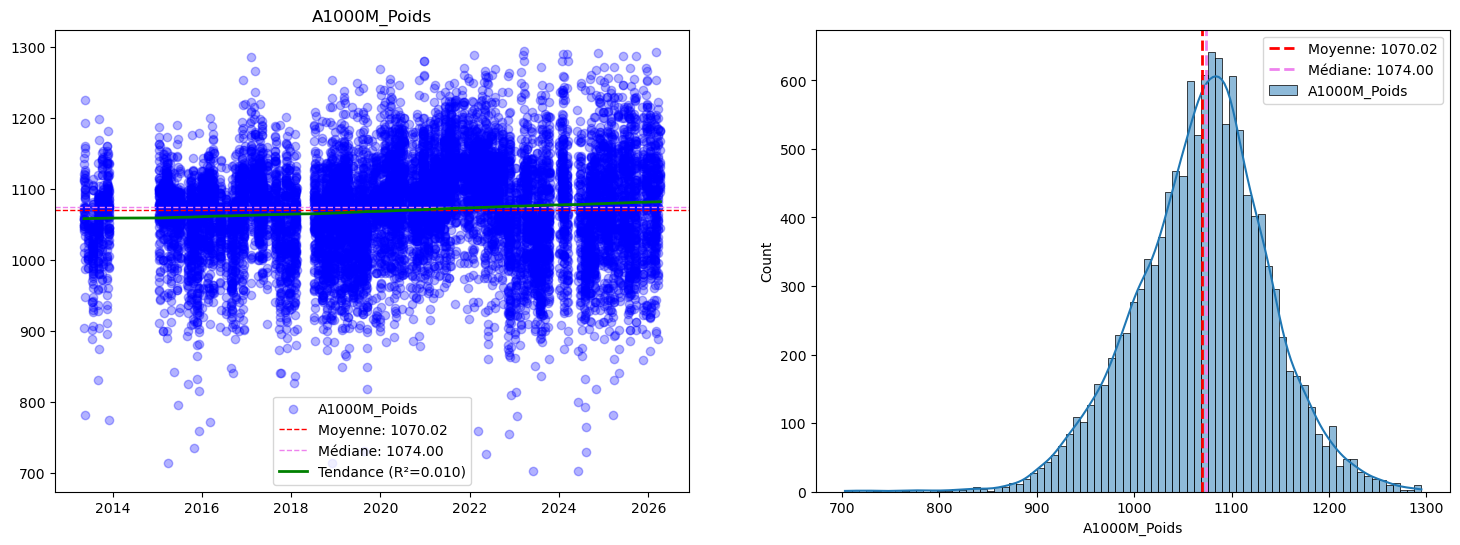

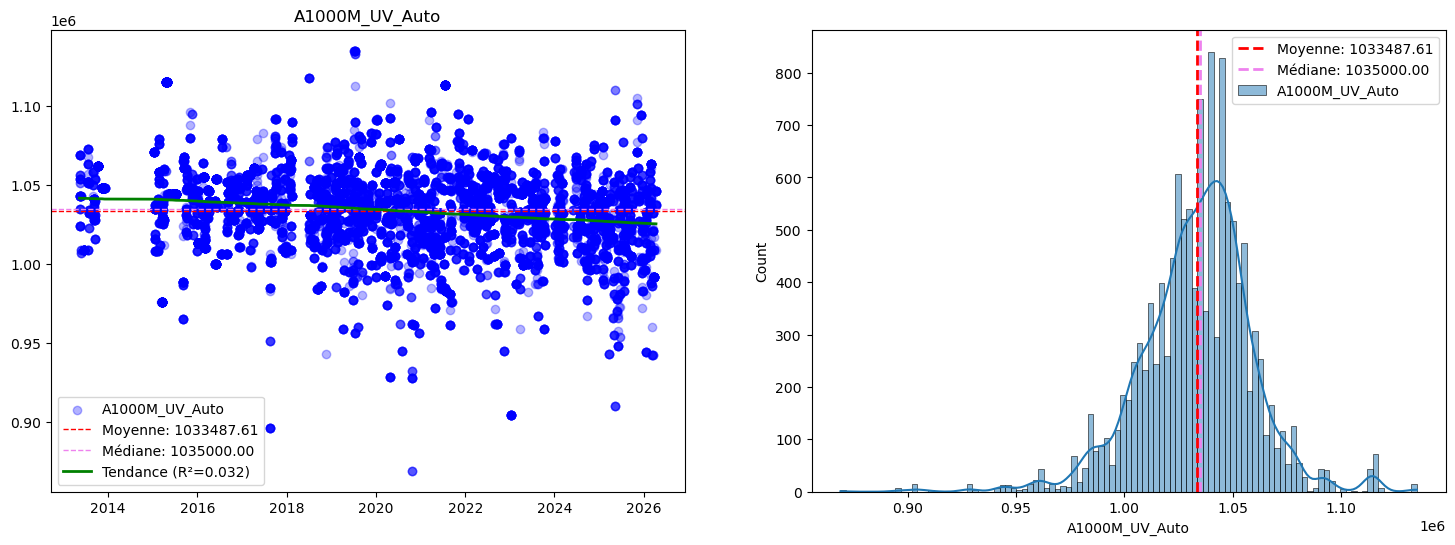

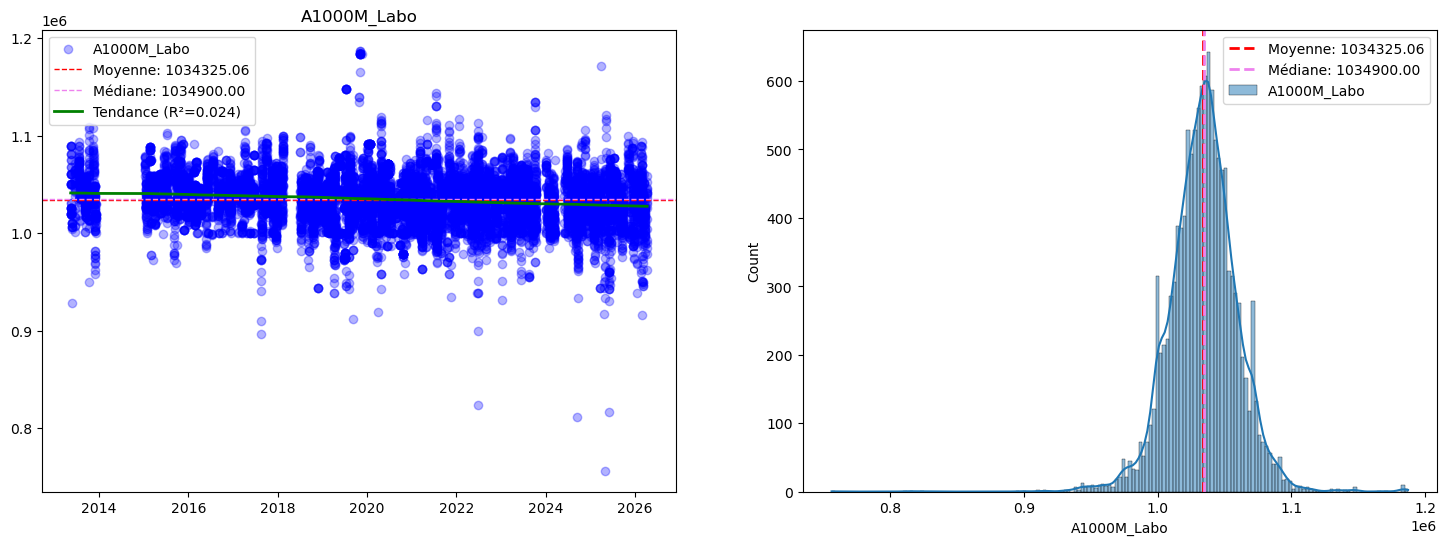

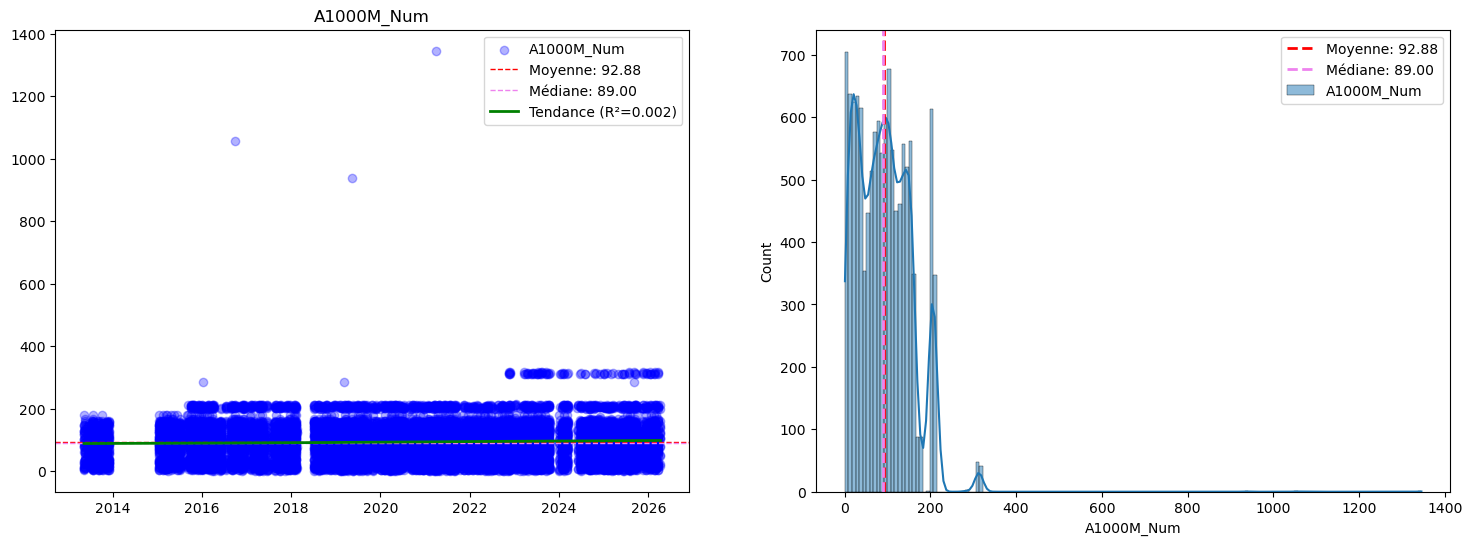

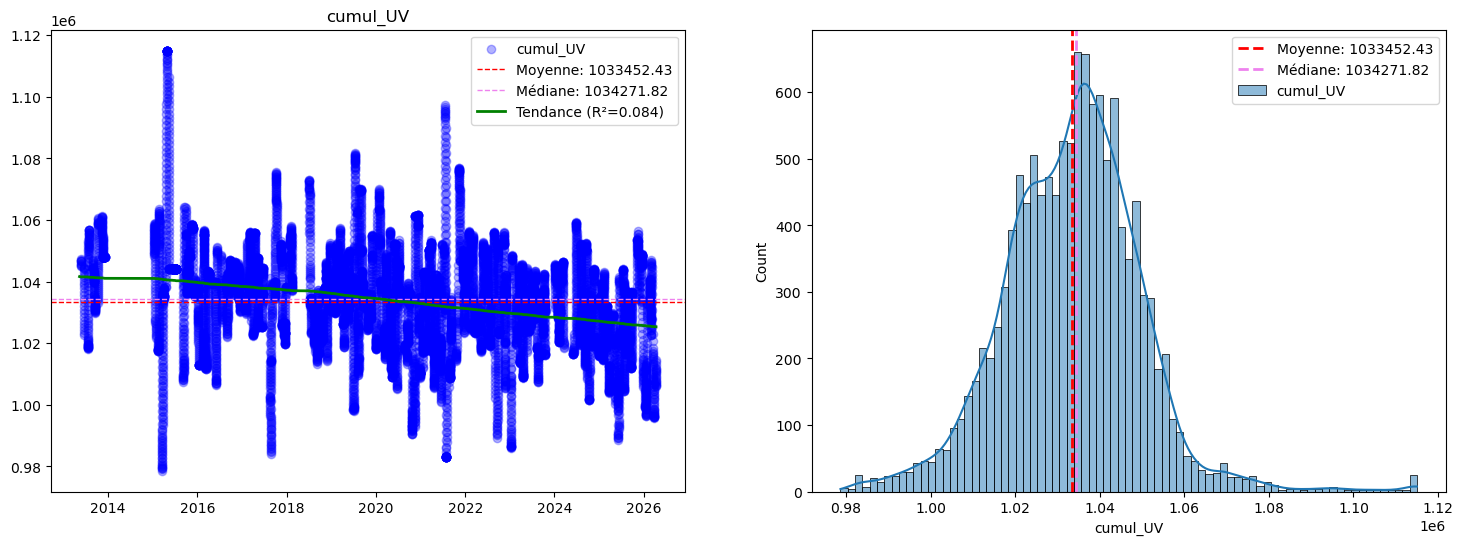

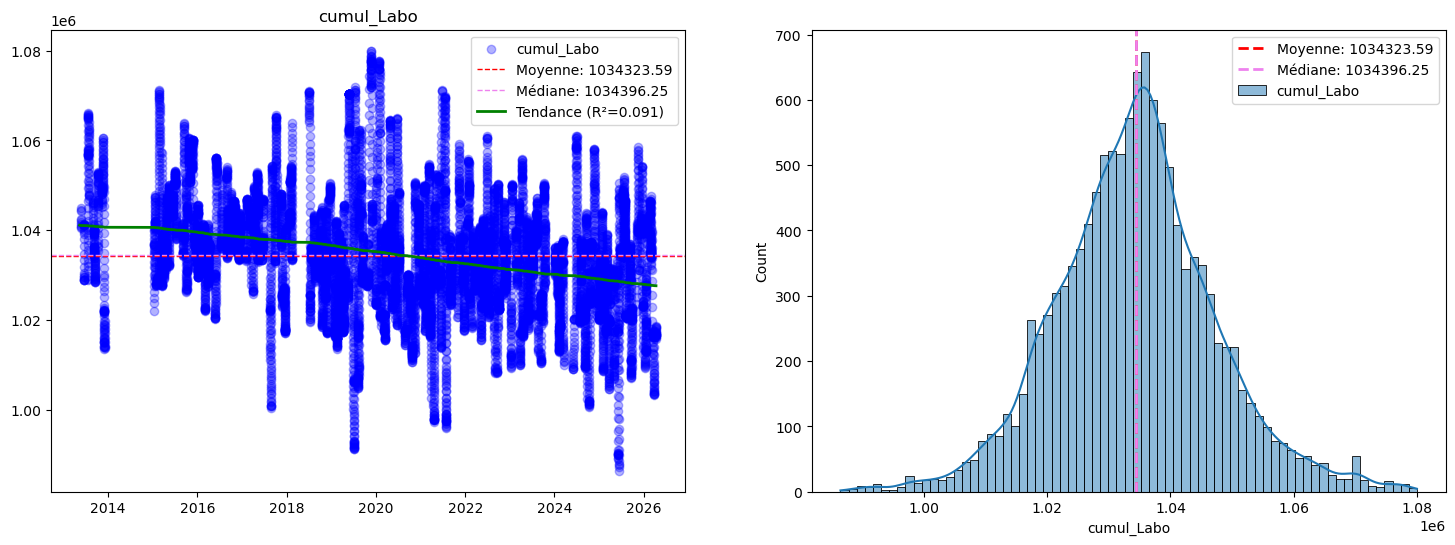

In [23]:
plot_data_v2(df_M, df_M_tags)

Campagnes identifiées : 192


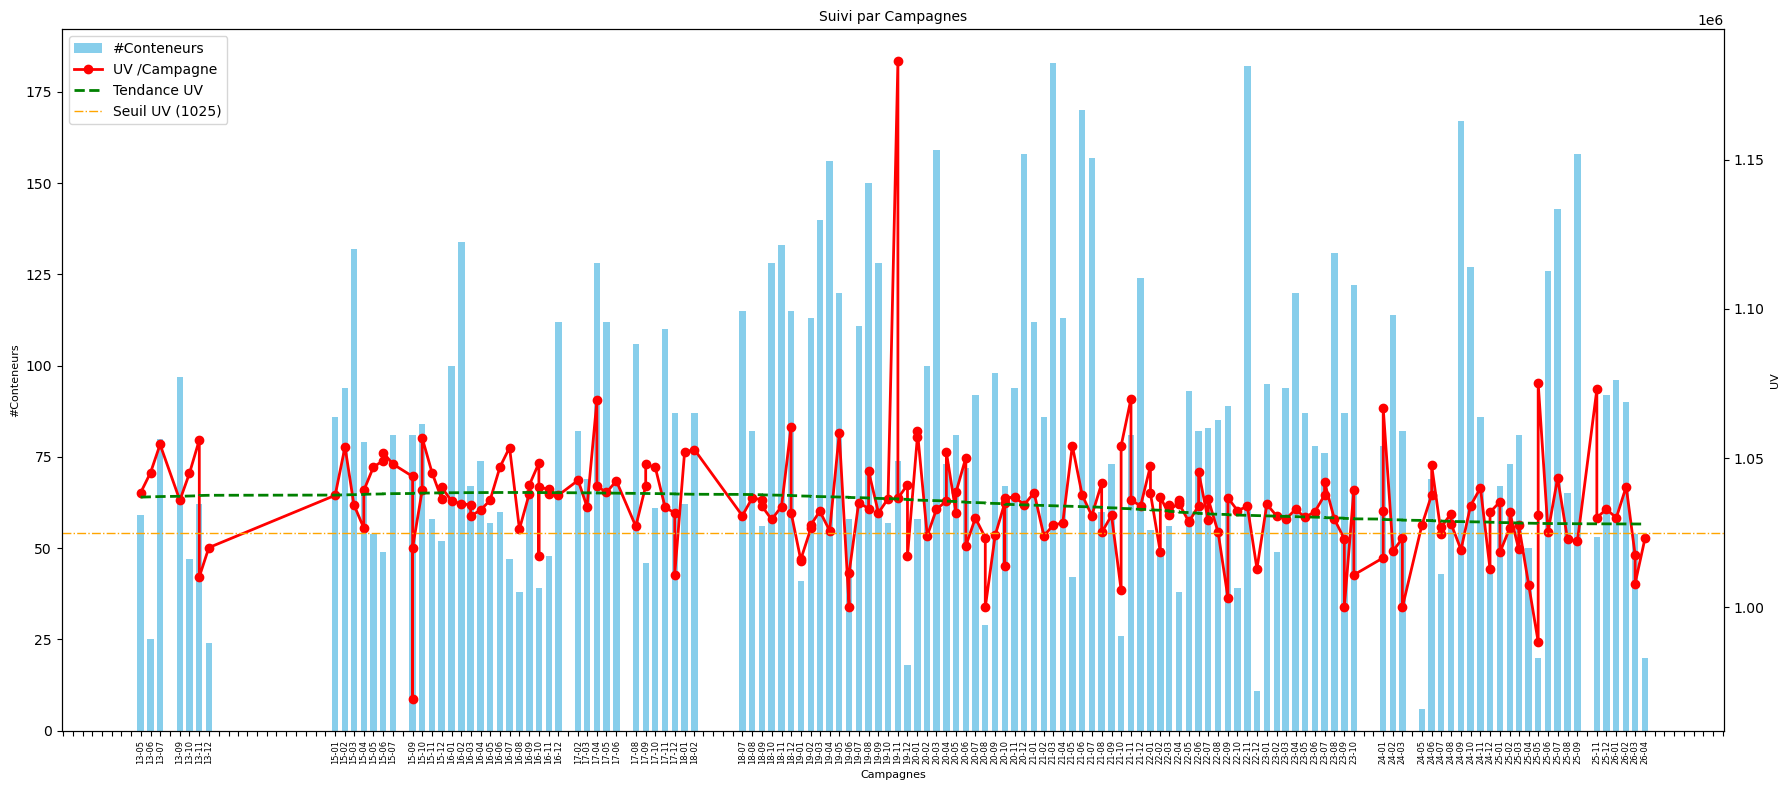

In [24]:
plot_campagnes_v5(campagnes)

In [25]:
def extract_xls(data,nom_fichier,index=False):
    df = data.copy()
    nom_fichier = nom_fichier+".xlsx"
    if (index):
        # Supprimer la timezone de l'index
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        # Corriger TOUTES les colonnes datetime avec timezone
        for col in df.columns:
            # Vérifier si c'est une colonne datetime
            if pd.api.types.is_datetime64_any_dtype(df[col]):
                # Si elle a une timezone, la supprimer
                if df[col].dt.tz is not None:
                    df[col] = df[col].dt.tz_localize(None)

    df.to_excel(nom_fichier, index=index)

    # Créer un lien de téléchargement
    #FileLink(fichier)
    display(HTML(f'<a href="{nom_fichier}" download>Télécharger les Data de ${nom_fichier}</a>'))

In [26]:
def extract():
    extract_xls(brute,'Formulation_brute',True)
    extract_xls(data,'Formulation_OI',True)
    extract_xls(result,'Formulation_traitees',True)
    extract_xls(campagnes,'Formulation_Campagnes',False)


In [27]:
# Convertir en Excel
fichier = 'Campagnes.xlsx'
campagnes.to_excel(fichier, index=False)

# Créer un lien de téléchargement
#FileLink(fichier)
#display(HTML(f'<a href="{fichier}" download>Télécharger le fichier Excel</a>'))

# Créer un bouton de téléchargement
html = f'''
<a href="data:application/vnd.openxmlformats-officedocument.spreadsheetml.sheet;base64,{data}" 
   download="{fichier}">
   <button>Télécharger Excel</button>
</a>
'''
display(HTML(html))

In [28]:
tags_H = ['CTY_FHA1000M_Teneur_VA','CTY_FHA1000R_Teneur_VA']
start_H = '2010-01-01'
end_H = '2025-12-01'
df_list_H = get_data(tags_H,start_H,end_H)
data_H = merge_data(df_list_H)
brute_H = data_H.copy()
#brute.columns = data_tags
brute_H.describe()

,CTY_FHA1000M_Teneur_VA,CTY_FHA1000R_Teneur_VA
count,1.969510e+05,1.945150e+05
mean,1.026298e+06,1.026168e+06
std,1.329558e+04,1.533494e+04
min,5.701004e+05,9.968070e+05
25%,1.017777e+06,1.011885e+06
50%,1.025840e+06,1.029056e+06
75%,1.033801e+06,1.036377e+06
max,1.075963e+06,1.062356e+06


In [29]:
def filtering_H(df):
    df = df.dropna(how="all")
    df = df[(df['CTY_FHA1000M_Teneur_VA']>700_000) & (df['CTY_FHA1000M_Teneur_VA']<1300_000)]
#    df = df.dropna(how="all", subset=['A1000M_Poids','A1000R_Poids'])
    return df

In [30]:
def ajouter_moyennes_glissantes_simple(df, window=10):
    """
    Ajoute une colonne de moyennes glissantes :
    - cumul_UV : moyenne de la colonne 1 sur les 10 dernières valeurs
    
    Parameters:
    df : DataFrame pandas
    window : int, nombre de valeurs pour la fenêtre glissante (défaut: 10)
    
    Returns:
    DataFrame avec les nouvelles colonnes
    """
    # Extraction des colonnes
    valeurs_uv = df.iloc[:, 0]
    
    # Calcul de la moyenne pondérée glissante pour UV
    numerateur_uv = (1 * valeurs_uv).rolling(window=window).mean()
    denominateur = 1.0 #poids.rolling(window=window).sum()
    df['cumul_UV'] = numerateur_uv / denominateur
        
    return df

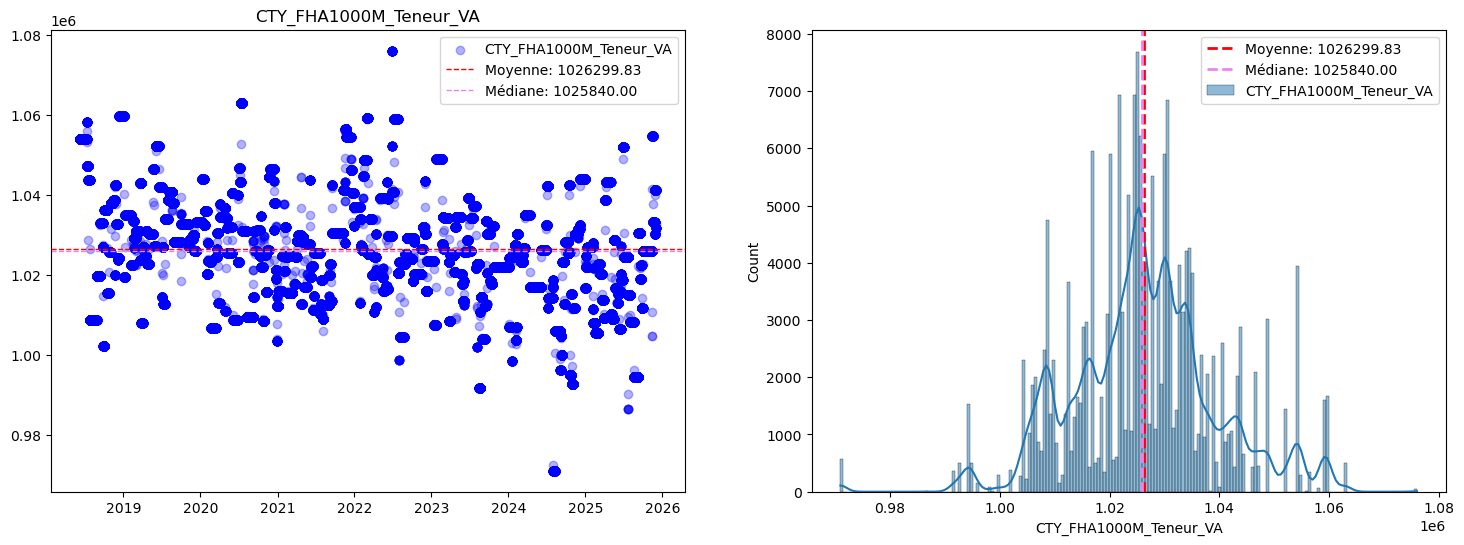

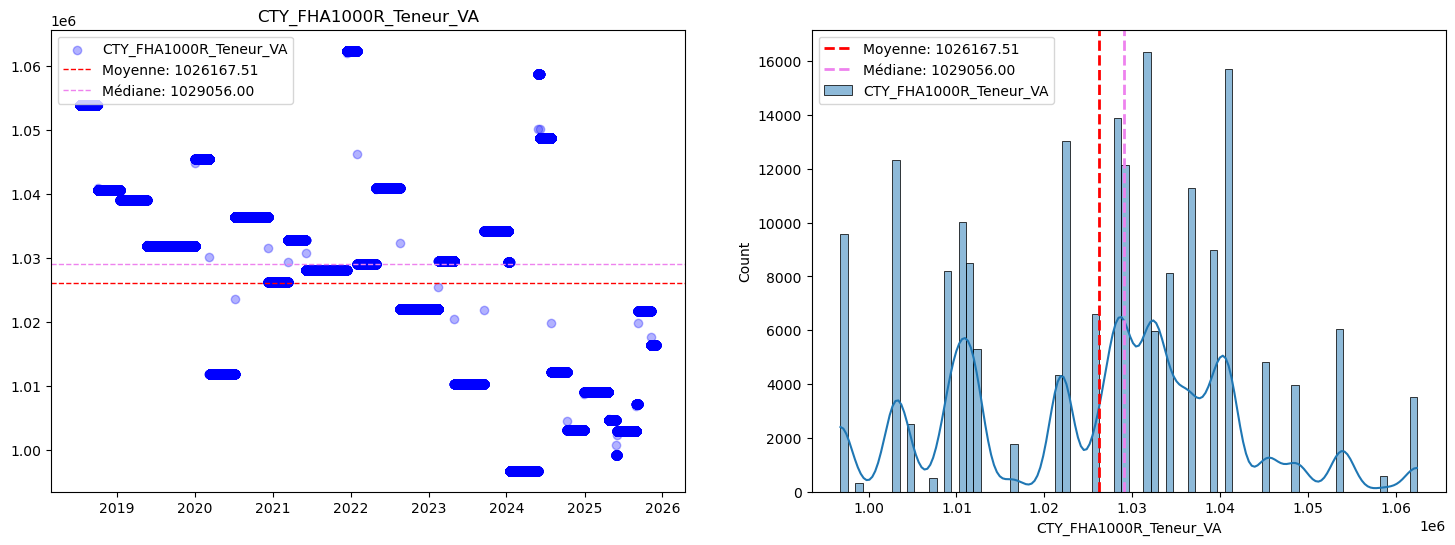

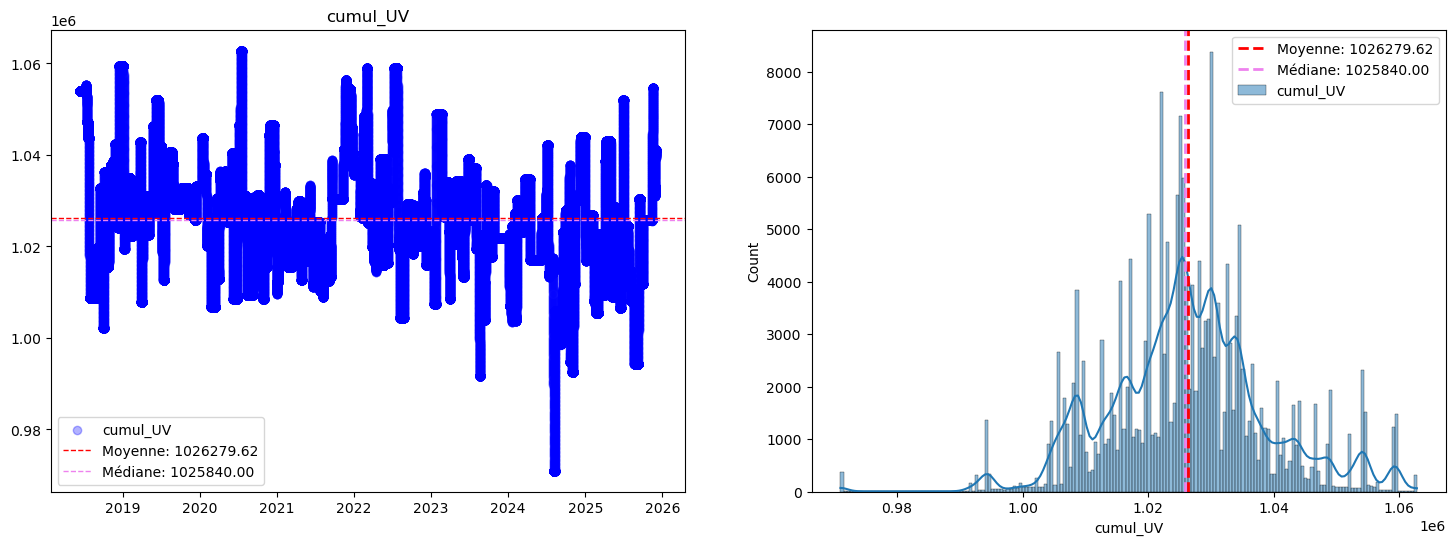

In [31]:
df_H = brute_H.copy()
df_H = filtering_H(df_H)
# Repérer les changement de campagne de M->R et R->M
#df_ = ajouter_element_campagne(df_, fill_empty=False)
# Séparation Campagnes A1000M et A1000R:
#df_M, df_R = separer_elements(df_)
# Detect changement de campagne vs jours :
#df_M= reincrementer_campagnes_par_temps(df_M, jours_seuil=2)
#df_R_updated = reincrementer_campagnes_par_temps(df_R, jours_seuil=2)
df_H = ajouter_moyennes_glissantes_simple(df_H,200)
#result = detecter_campagnes_v2(result, seuil_jours=14)
#campagnes = resume_par_campagne(df_M)
tags_H_ = df_H.columns.tolist()[:]
#df_M_tags =  ['A1000M_Poids','A1000M_UV_Auto','A1000M_Labo','A1000M_Num','cumul_UV','cumul_Labo']
plot_data(df_H, tags_H_)

In [32]:
df_H

,CTY_FHA1000M_Teneur_VA,CTY_FHA1000R_Teneur_VA,cumul_UV
timestamp,,,
2018-06-06 13:40:00+00:00,1054000.0,NaN,NaN
2018-06-06 14:00:00+00:00,1054000.0,NaN,NaN
2018-06-06 14:20:00+00:00,1054000.0,NaN,NaN
2018-06-06 14:40:00+00:00,1054000.0,NaN,NaN
2018-06-06 15:00:00+00:00,1054000.0,NaN,NaN
...,...,...,...
2025-12-01 22:20:00+00:00,1031752.0,1016375.0,1.039943e+06
2025-12-01 22:40:00+00:00,1031752.0,1016375.0,1.039896e+06
2025-12-01 23:00:00+00:00,1031752.0,1016375.0,1.039849e+06


In [33]:
tags_

['A1000M_Poids',
 'A1000M_UV_Auto',
 'A1000M_Labo',
 'A1000M_Num',
 'campagne',
 'mois_annee',
 'mois_annee_dt',
 'cumul_UV']

In [34]:
df_M

,A1000M_Poids,A1000M_UV_Auto,A1000M_Labo,A1000M_Num,campagne,mois_annee,mois_annee_dt,cumul_UV,cumul_Labo,UV_pondere,UV_labo
timestamp,,,,,,,,,,,
2013-05-12 23:00:00+00:00,1048.0,1035000.0,1.026245e+06,90.0,1,13-05,2013-05-01,NaN,NaN,1.084680e+09,1.075505e+09
2013-05-12 23:20:00+00:00,1135.0,1035000.0,1.026245e+06,21.0,1,13-05,2013-05-01,NaN,NaN,1.174725e+09,1.164788e+09
2013-05-13 03:00:00+00:00,1111.0,1035000.0,1.026245e+06,102.0,1,13-05,2013-05-01,NaN,NaN,1.149885e+09,1.140158e+09
2013-05-13 04:40:00+00:00,1144.0,1035000.0,1.026245e+06,127.0,1,13-05,2013-05-01,NaN,NaN,1.184040e+09,1.174024e+09
2013-05-13 07:20:00+00:00,1073.0,1035000.0,1.026245e+06,61.0,1,13-05,2013-05-01,NaN,NaN,1.110555e+09,1.101161e+09
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09 16:00:00+00:00,1123.0,1037000.0,1.004372e+06,24.0,137,26-04,2026-04-01,1.011731e+06,1.018659e+06,1.164551e+09,1.127910e+09
2026-04-09 18:00:00+00:00,1100.0,1037000.0,9.925467e+05,200.0,137,26-04,2026-04-01,1.012051e+06,1.018143e+06,1.140700e+09,1.091801e+09
2026-04-10 00:00:00+00:00,1096.0,1037000.0,9.896000e+05,48.0,137,26-04,2026-04-01,1.012902e+06,1.017884e+06,1.136552e+09,1.084602e+09


In [35]:
# %% [markdown]
# # Analyse de Corrélation : A1000M_Poids vs prix_ve
# 
# Cette analyse calcule différentes métriques de corrélation entre les prix VE (Voiture Électrique) 
# et VA (Voiture à Autonomie/Automatique).

# %% [markdown]
# ## 1. Types de corrélations calculées
# 
# ### Corrélation de Pearson (r)
# - **Définition** : Mesure la relation **linéaire** entre deux variables
# - **Valeurs** : Entre -1 (corrélation négative parfaite) et +1 (corrélation positive parfaite)
# - **Interprétation** : 
#   - r = 0 : Aucune corrélation linéaire
#   - 0 < |r| < 0.3 : Corrélation faible
#   - 0.3 ≤ |r| < 0.7 : Corrélation modérée
#   - 0.7 ≤ |r| ≤ 1 : Corrélation forte
# - **Sensible aux valeurs aberrantes** : Oui
# 
# ### Corrélation de Spearman (ρ)
# - **Définition** : Mesure la relation **monotone** (pas nécessairement linéaire) basée sur les rangs
# - **Avantage** : Robuste aux valeurs aberrantes et aux relations non-linéaires
# - **Usage** : Préférable quand la relation n'est pas strictement linéaire
# 
# ### Corrélation de Kendall (τ)
# - **Définition** : Mesure la concordance entre les rangs de deux variables
# - **Avantage** : Très robuste, bon pour petits échantillons
# - **Interprétation** : Probabilité de concordance vs discordance
# 
# ### Coefficient de détermination (R²)
# - **Définition** : R² = r² (carré de la corrélation de Pearson)
# - **Interprétation** : Pourcentage de variance d'une variable expliquée par l'autre
# - **Exemple** : R² = 0.64 signifie que 64% de la variabilité de prix_ve est expliquée par prix_va

# %%
df = df_M.copy()
print("=" * 60)
print("ANALYSE DE CORRÉLATION : A1000M_Poids vs A1000M_UV_Auto")
print("=" * 60)

# 1. Corrélation de Pearson (linéaire)
pearson_corr = df['A1000M_Poids'].corr(df['A1000M_UV_Auto'], method='pearson')
print(f"\n1. Corrélation de Pearson (linéaire) : {pearson_corr:.4f}")

# 2. Corrélation de Spearman (monotone, non linéaire)
spearman_corr = df['A1000M_Poids'].corr(df['A1000M_UV_Auto'], method='spearman')
print(f"2. Corrélation de Spearman (rang)     : {spearman_corr:.4f}")

# 3. Corrélation de Kendall
kendall_corr = df['A1000M_Poids'].corr(df['A1000M_UV_Auto'], method='kendall')
print(f"3. Corrélation de Kendall (tau)       : {kendall_corr:.4f}")

# 4. Coefficient de détermination (R²)
r_squared = pearson_corr ** 2
print(f"4. Coefficient de détermination (R²)  : {r_squared:.4f}")
print(f"   → {r_squared*100:.2f}% de la variance de A1000M_UV_Auto est expliquée par A1000M_Poids")

# %% [markdown]
# ## 2. Interprétation des résultats
# 
# ### Force de la corrélation (selon Pearson)
# - **Si |r| < 0.3** : Corrélation faible → peu de relation linéaire
# - **Si 0.3 ≤ |r| < 0.7** : Corrélation modérée → relation linéaire moyenne
# - **Si |r| ≥ 0.7** : Corrélation forte → forte relation linéaire
# 
# ### Comparaison Pearson vs Spearman
# - **Si Pearson ≈ Spearman** : La relation est linéaire
# - **Si Spearman > Pearson** : La relation est monotone mais non-linéaire
# - **Si très différents** : Présence possible de valeurs aberrantes ou relation complexe

# %%
# Matrice de corrélation complète
correlation_matrix = df[['A1000M_Poids', 'A1000M_UV_Auto']].corr()

print("\n" + "=" * 60)
print("MATRICE DE CORRÉLATION")
print("=" * 60)
print(correlation_matrix)

ANALYSE DE CORRÉLATION : A1000M_Poids vs A1000M_UV_Auto

1. Corrélation de Pearson (linéaire) : -0.0520
2. Corrélation de Spearman (rang)     : -0.0488
3. Corrélation de Kendall (tau)       : -0.0327
4. Coefficient de détermination (R²)  : 0.0027
   → 0.27% de la variance de A1000M_UV_Auto est expliquée par A1000M_Poids

MATRICE DE CORRÉLATION
                A1000M_Poids  A1000M_UV_Auto
A1000M_Poids        1.000000       -0.052013
A1000M_UV_Auto     -0.052013        1.000000


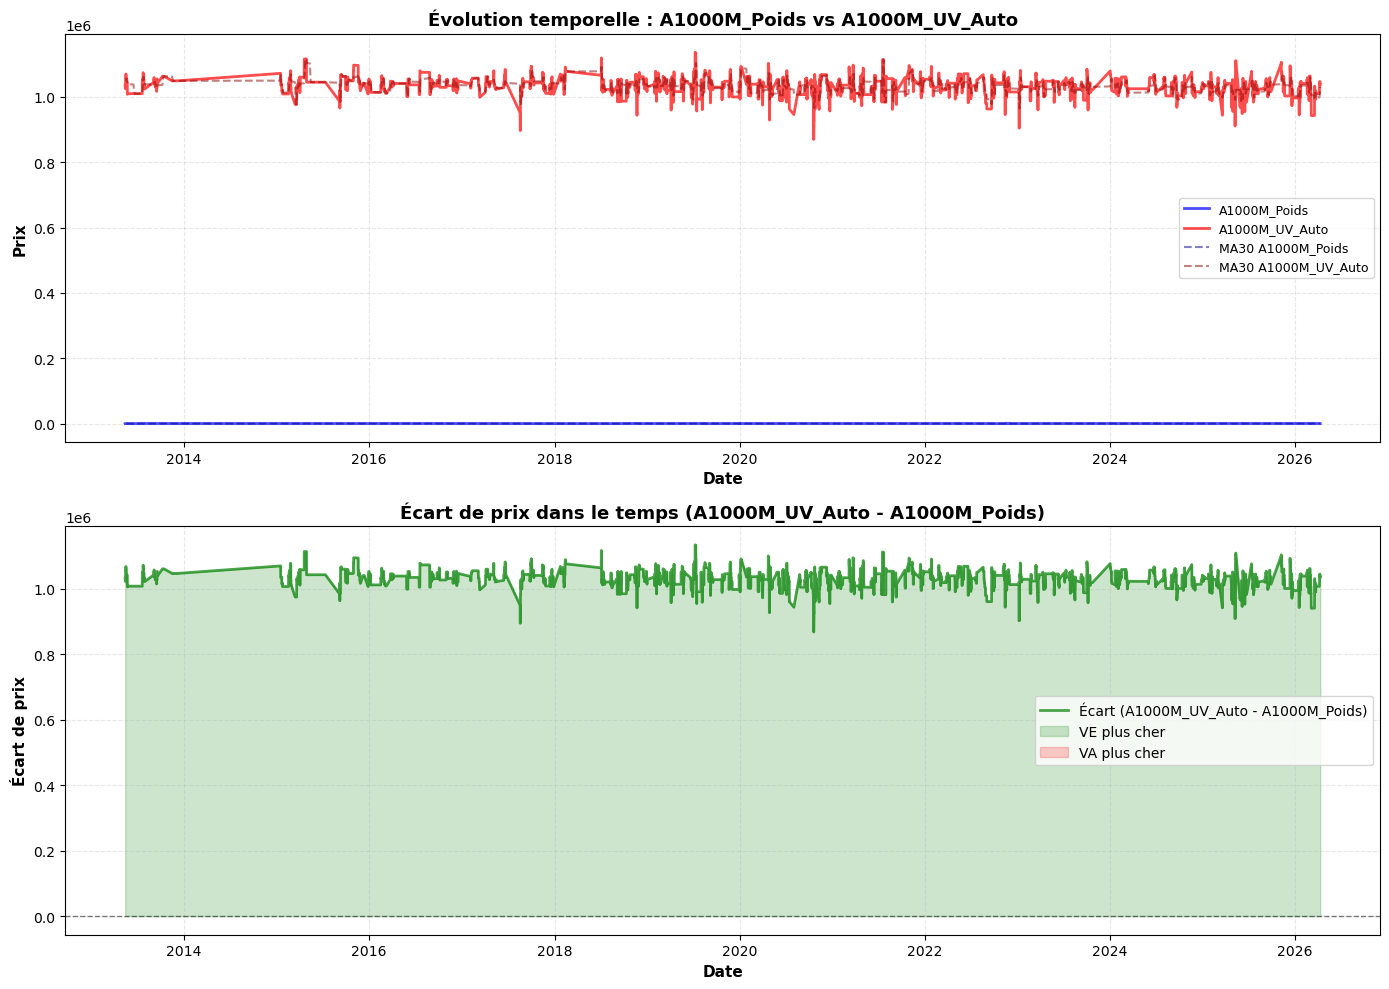

In [36]:
# %% [markdown]
# ## 3. Évolution temporelle des prix
# 
# ### Graphique temporel
# - Visualisation de l'évolution des prix VE et VA dans le temps
# - Permet d'identifier :
#   - Les **tendances** : croissance, décroissance, stagnation
#   - Les **cycles** : variations saisonnières ou périodiques
#   - Les **événements** : chocs, ruptures, anomalies
#   - La **volatilité** : stabilité ou instabilité des prix
# - **Écart prix_ve - prix_va** : Différence entre les deux prix dans le temps
#   - Positif : prix_ve > prix_va (VE plus cher)
#   - Négatif : prix_ve < prix_va (VA plus cher)

# %%
# Créer une figure avec 2 sous-graphiques
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 : Évolution temporelle des deux prix
axes[0].plot(df.index, df['A1000M_Poids'], label='A1000M_Poids', linewidth=2, color='blue', alpha=0.7)
axes[0].plot(df.index, df['A1000M_UV_Auto'], label='A1000M_UV_Auto', linewidth=2, color='red', alpha=0.7)
axes[0].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Prix', fontsize=11, fontweight='bold')
axes[0].set_title('Évolution temporelle : A1000M_Poids vs A1000M_UV_Auto', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Ajouter les moyennes mobiles (optionnel)
if len(df) > 30:
    window = min(30, len(df) // 10)  # Fenêtre adaptative
    ma_va = df['A1000M_Poids'].rolling(window=window).mean()
    ma_ve = df['A1000M_UV_Auto'].rolling(window=window).mean()
    axes[0].plot(df.index, ma_va, '--', linewidth=1.5, color='darkblue', 
                 alpha=0.5, label=f'MA{window} A1000M_Poids')
    axes[0].plot(df.index, ma_ve, '--', linewidth=1.5, color='darkred', 
                 alpha=0.5, label=f'MA{window} A1000M_UV_Auto')
    axes[0].legend(loc='best', fontsize=9)

# Graphique 2 : Écart entre les prix (A1000M_UV_Auto - A1000M_Poids)
ecart = df['A1000M_UV_Auto'] - df['A1000M_Poids']
axes[1].plot(df.index, ecart, linewidth=2, color='green', alpha=0.7, label='Écart (A1000M_UV_Auto - A1000M_Poids)')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].fill_between(df.index, ecart, 0, where=(ecart >= 0), 
                      color='green', alpha=0.2, label='VE plus cher')
axes[1].fill_between(df.index, ecart, 0, where=(ecart < 0), 
                      color='red', alpha=0.2, label='VA plus cher')
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Écart de prix', fontsize=11, fontweight='bold')
axes[1].set_title('Écart de prix dans le temps (A1000M_UV_Auto - A1000M_Poids)', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()



STATISTIQUES SUR L'ÉCART DE PRIX
Écart moyen (A1000M_UV_Auto - A1000M_Poids)       : 1032417.59
Écart médian                          : 1034015.50
Écart-type                            : 26109.16
Écart minimum                         : 868014.00
Écart maximum                         : 1134060.00
% du temps où A1000M_UV_Auto > A1000M_Poids       : 100.0%
% du temps où A1000M_UV_Auto < A1000M_Poids       : 0.0%

STATISTIQUES SUR LES RENDEMENTS (variations en %)

--- Prix VA ---
Rendement moyen           : 0.2845%
Rendement médian          : -0.0905%
Volatilité (écart-type)   : 7.6279%
Rendement min             : -34.3580%
Rendement max             : 70.9815%

--- Prix VE ---
Rendement moyen           : 0.0041%
Rendement médian          : 0.0000%
Volatilité (écart-type)   : 0.9080%
Rendement min             : -13.2507%
Rendement max             : 19.8901%

--- Comparaison ---
Ratio volatilité VE/VA    : 0.12
→ Prix VA est 8.40x plus volatil que prix VE


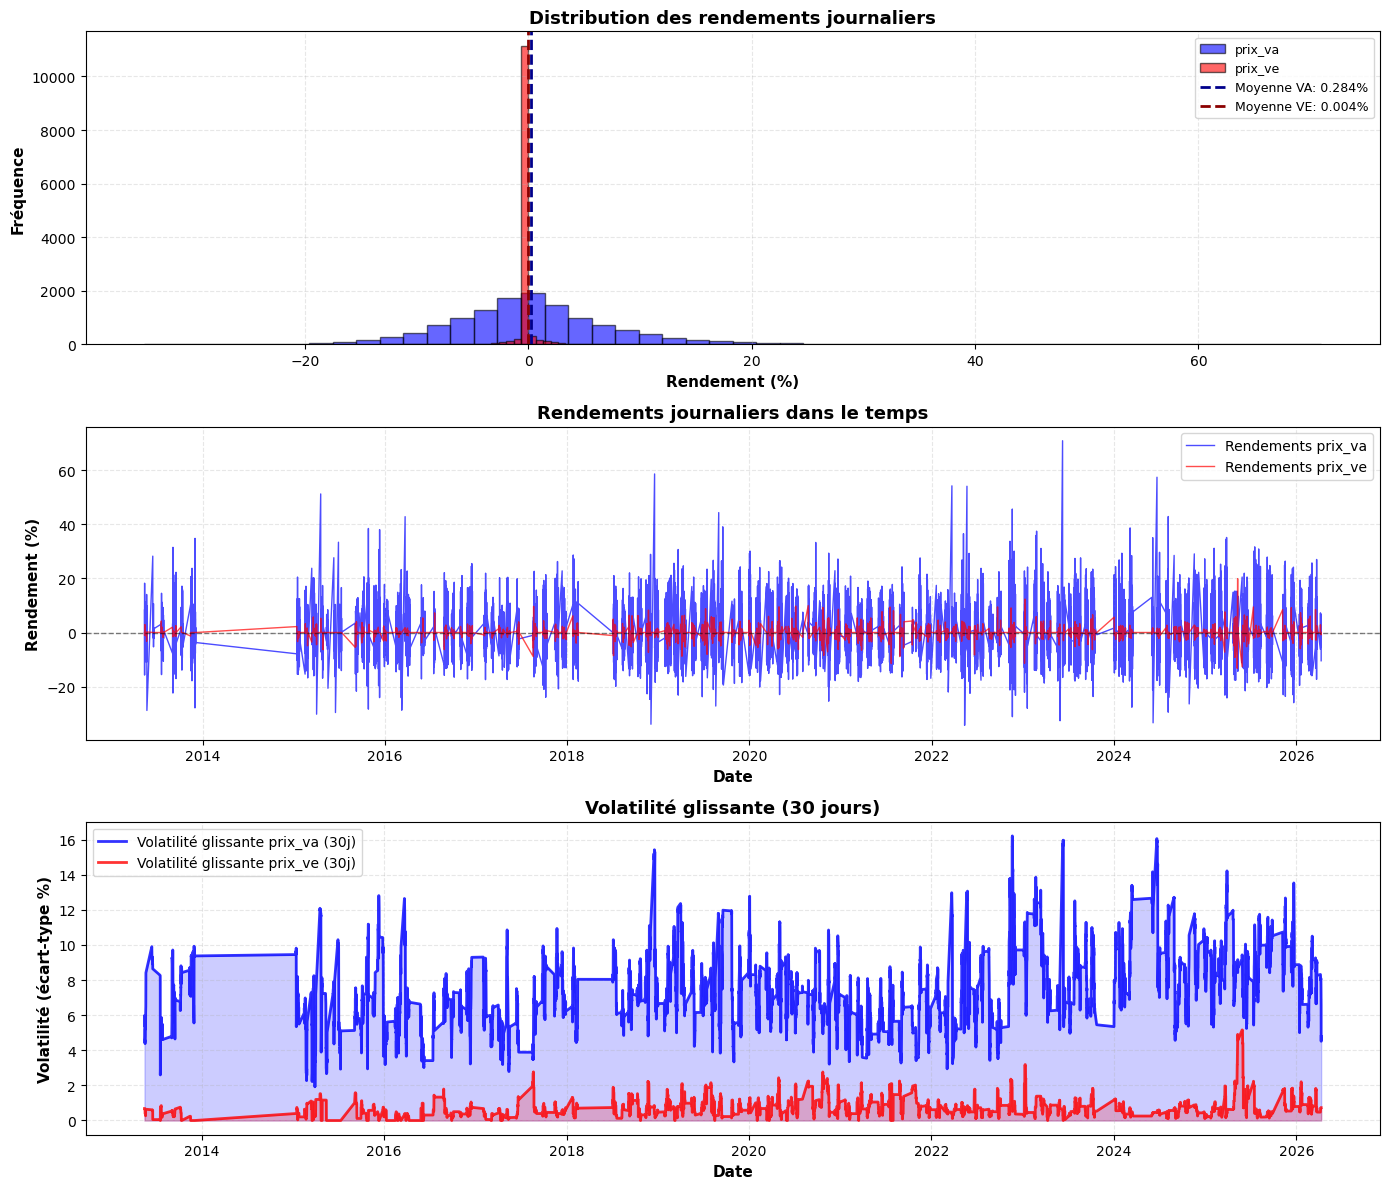

In [37]:
# Statistiques sur l'écart
print("\n" + "=" * 60)
print("STATISTIQUES SUR L'ÉCART DE PRIX")
print("=" * 60)
print(f"Écart moyen (A1000M_UV_Auto - A1000M_Poids)       : {ecart.mean():.2f}")
print(f"Écart médian                          : {ecart.median():.2f}")
print(f"Écart-type                            : {ecart.std():.2f}")
print(f"Écart minimum                         : {ecart.min():.2f}")
print(f"Écart maximum                         : {ecart.max():.2f}")
print(f"% du temps où A1000M_UV_Auto > A1000M_Poids       : {(ecart > 0).sum() / len(ecart) * 100:.1f}%")
print(f"% du temps où A1000M_UV_Auto < A1000M_Poids       : {(ecart < 0).sum() / len(ecart) * 100:.1f}%")

# %% [markdown]
# ## 4. Analyse de volatilité
# 
# ### Qu'est-ce que la volatilité ?
# - **Définition** : Mesure de la dispersion des rendements (variation des prix) autour de leur moyenne
# - **Importance** : Indicateur de risque et d'incertitude sur les prix
# - **Interprétation** :
#   - Volatilité élevée = Prix instables, risque élevé, grandes variations
#   - Volatilité faible = Prix stables, risque faible, petites variations
# 
# ### Méthodes de calcul :
# 
# #### 1. Rendements (Returns)
# - **Définition** : Variation relative du prix entre deux périodes
# - **Formule** : return_t = (prix_t - prix_{t-1}) / prix_{t-1} × 100
# - **Interprétation** : Pourcentage de variation du prix
# 
# #### 2. Volatilité (Écart-type des rendements)
# - **Définition** : Écart-type des rendements sur une période
# - **Usage** : Mesure la dispersion des variations de prix
# - **Plus l'écart-type est élevé, plus les prix sont volatils**
# 
# #### 3. Volatilité glissante (Rolling Volatility)
# - **Définition** : Volatilité calculée sur une fenêtre mobile (ex: 30 jours)
# - **Avantage** : Permet de voir comment la volatilité évolue dans le temps
# - **Usage** : Identifier les périodes de forte/faible volatilité

# %%
# Calcul des rendements (variations en pourcentage)
returns_va = df['A1000M_Poids'].pct_change() * 100  # En pourcentage
returns_ve = df['A1000M_UV_Auto'].pct_change() * 100  # En pourcentage

# Supprimer la première valeur NaN
returns_va = returns_va.dropna()
returns_ve = returns_ve.dropna()

# Statistiques sur les rendements
print("\n" + "=" * 60)
print("STATISTIQUES SUR LES RENDEMENTS (variations en %)")
print("=" * 60)

print("\n--- Prix VA ---")
print(f"Rendement moyen           : {returns_va.mean():.4f}%")
print(f"Rendement médian          : {returns_va.median():.4f}%")
print(f"Volatilité (écart-type)   : {returns_va.std():.4f}%")
print(f"Rendement min             : {returns_va.min():.4f}%")
print(f"Rendement max             : {returns_va.max():.4f}%")

print("\n--- Prix VE ---")
print(f"Rendement moyen           : {returns_ve.mean():.4f}%")
print(f"Rendement médian          : {returns_ve.median():.4f}%")
print(f"Volatilité (écart-type)   : {returns_ve.std():.4f}%")
print(f"Rendement min             : {returns_ve.min():.4f}%")
print(f"Rendement max             : {returns_ve.max():.4f}%")

# Comparaison
print("\n--- Comparaison ---")
ratio_vol = returns_ve.std() / returns_va.std()
print(f"Ratio volatilité VE/VA    : {ratio_vol:.2f}")
if ratio_vol > 1:
    print(f"→ Prix VE est {ratio_vol:.2f}x plus volatil que prix VA")
else:
    print(f"→ Prix VA est {1/ratio_vol:.2f}x plus volatil que prix VE")

# %%
# Calcul de la volatilité glissante (rolling volatility)
if len(df) > 30:
    window_vol = min(30, len(df) // 10)  # Fenêtre adaptative
else:
    window_vol = max(5, len(df) // 5)

rolling_vol_va = returns_va.rolling(window=window_vol).std()
rolling_vol_ve = returns_ve.rolling(window=window_vol).std()

# Créer une figure avec 3 sous-graphiques pour la volatilité
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Graphique 1 : Distribution des rendements (histogrammes)
axes[0].hist(returns_va, bins=50, alpha=0.6, color='blue', label='prix_va', edgecolor='black')
axes[0].hist(returns_ve, bins=50, alpha=0.6, color='red', label='prix_ve', edgecolor='black')
axes[0].axvline(returns_va.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Moyenne VA: {returns_va.mean():.3f}%')
axes[0].axvline(returns_ve.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Moyenne VE: {returns_ve.mean():.3f}%')
axes[0].set_xlabel('Rendement (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution des rendements journaliers', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Graphique 2 : Rendements dans le temps
axes[1].plot(returns_va.index, returns_va, linewidth=1, color='blue', alpha=0.7, label='Rendements prix_va')
axes[1].plot(returns_ve.index, returns_ve, linewidth=1, color='red', alpha=0.7, label='Rendements prix_ve')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Rendement (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Rendements journaliers dans le temps', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

# Graphique 3 : Volatilité glissante
axes[2].plot(rolling_vol_va.index, rolling_vol_va, linewidth=2, color='blue', 
             alpha=0.8, label=f'Volatilité glissante prix_va ({window_vol}j)')
axes[2].plot(rolling_vol_ve.index, rolling_vol_ve, linewidth=2, color='red', 
             alpha=0.8, label=f'Volatilité glissante prix_ve ({window_vol}j)')
axes[2].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Volatilité (écart-type %)', fontsize=11, fontweight='bold')
axes[2].set_title(f'Volatilité glissante ({window_vol} jours)', fontsize=13, fontweight='bold')
axes[2].legend(loc='best', fontsize=10)
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].fill_between(rolling_vol_va.index, rolling_vol_va, alpha=0.2, color='blue')
axes[2].fill_between(rolling_vol_ve.index, rolling_vol_ve, alpha=0.2, color='red')

plt.tight_layout()
plt.show()


CORRÉLATION DES RENDEMENTS
Corrélation des rendements VA-VE : -0.0223

Interprétation :
→ Les variations de prix sont faiblement corrélées
→ Les deux prix évoluent de manière relativement indépendante


KeyError: 'V'

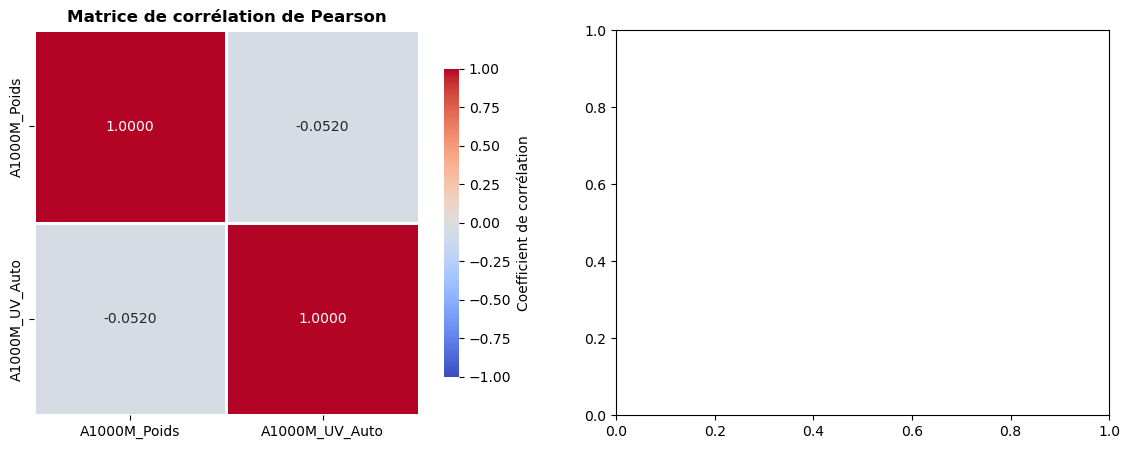

In [38]:
# %% [markdown]
# ### Interprétation de la volatilité
# 
# #### Distribution des rendements :
# - **Forme de la distribution** : 
#   - Normale (gaussienne) : rendements symétriques autour de la moyenne
#   - Asymétrique : présence de biais (skewness)
#   - Queues épaisses : événements extrêmes fréquents (kurtosis élevé)
# 
# #### Volatilité glissante :
# - **Pics de volatilité** : Périodes d'incertitude, événements marquants
# - **Creux de volatilité** : Périodes de stabilité
# - **Tendances** : Volatilité croissante ou décroissante dans le temps
# 
# #### Comparaison VA vs VE :
# - Si volatilité VE > volatilité VA : Prix VE plus risqué/incertain
# - Si volatilités similaires : Risque comparable
# - Corrélation des volatilités : Les deux prix réagissent-ils ensemble aux chocs ?

# %%
# Analyse complémentaire : corrélation des rendements
corr_returns = returns_va.corr(returns_ve)
print("\n" + "=" * 60)
print("CORRÉLATION DES RENDEMENTS")
print("=" * 60)
print(f"Corrélation des rendements VA-VE : {corr_returns:.4f}")
print("\nInterprétation :")
if abs(corr_returns) > 0.7:
    print("→ Les variations de prix sont fortement corrélées")
    print("→ Les deux prix réagissent de manière similaire aux chocs")
elif abs(corr_returns) > 0.3:
    print("→ Les variations de prix sont modérément corrélées")
    print("→ Les deux prix ont tendance à évoluer ensemble")
else:
    print("→ Les variations de prix sont faiblement corrélées")
    print("→ Les deux prix évoluent de manière relativement indépendante")

# %% [markdown]
# ## 5. Visualisations de corrélation
# 
# ### Graphique : Heatmap de corrélation
# - Représentation visuelle de la matrice de corrélation
# - **Rouge** : Corrélation négative
# - **Bleu** : Corrélation positive
# - **Blanc** : Pas de corrélation
# 
# ### Graphique : Scatter plot
# - Visualisation directe de la relation entre prix_va et prix_ve
# - Permet d'identifier visuellement la linéarité et les valeurs aberrantes

# %%
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de corrélation
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.4f', 
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,  # Échelle fixe de -1 à 1
            square=True, 
            linewidths=2,
            cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation"},
            ax=axes[0])
axes[0].set_title('Matrice de corrélation de Pearson', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Pairplot simplifié
axes[1].scatter(df['V'], df['A1000M_UV_Auto'], alpha=0.5, s=20, c='steelblue', 
                edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('A1000M_Poids', fontsize=11, fontweight='bold')
axes[1].set_ylabel('A1000M_UV_Auto', fontsize=11, fontweight='bold')
axes[1].set_title(f'Scatter plot (r = {pearson_corr:.4f}, R² = {r_squared:.4f})', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')

# Ajouter la ligne de régression si corrélation significative
if abs(pearson_corr) > 0.3:
    z = np.polyfit(df['prix_va'], df['prix_ve'], 1)
    p = np.poly1d(z)
    axes[1].plot(df['prix_va'], p(df['prix_va']), "r--", linewidth=2, alpha=0.7, 
                 label=f'Régression linéaire')
    axes[1].legend()

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 6. Résumé statistique
# 
# Le tableau ci-dessous fournit un résumé complet des corrélations calculées :

# %%
# Créer un résumé en DataFrame
summary = pd.DataFrame({
    'Méthode': ['Pearson', 'Spearman', 'Kendall', 'R²'],
    'Valeur': [pearson_corr, spearman_corr, kendall_corr, r_squared],
    'Interprétation': [
        'Corrélation linéaire',
        'Corrélation monotone (rangs)',
        'Concordance des rangs',
        'Variance expliquée'
    ]
})

print("\n" + "=" * 60)
print("RÉSUMÉ DES CORRÉLATIONS")
print("=" * 60)
print(summary.to_string(index=False))

# Résumé volatilité
summary_vol = pd.DataFrame({
    'Variable': ['prix_va', 'prix_ve'],
    'Volatilité (%)': [returns_va.std(), returns_ve.std()],
    'Rendement moyen (%)': [returns_va.mean(), returns_ve.mean()],
    'Rendement min (%)': [returns_va.min(), returns_ve.min()],
    'Rendement max (%)': [returns_va.max(), returns_ve.max()]
})

print("\n" + "=" * 60)
print("RÉSUMÉ DE LA VOLATILITÉ")
print("=" * 60)
print(summary_vol.to_string(index=False))